In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
MODEL_PATH = "../model/"
VISUAL_PATH = "../visualization/"

In [4]:
df = pd.read_csv(RAW_PATH + "credit_risk_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [10]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().sum().values / len(df)) * 100
})

missing_values[missing_values["missing_count"] > 0]

,column,missing_count,missing_percent
3,person_emp_length,895,2.747000
7,loan_int_rate,3116,9.563856


In [12]:
target_distribution = df["loan_status"].value_counts().reset_index()
target_distribution.columns = ["loan_status", "count"]
target_distribution["percentage"] = target_distribution["count"] / len(df) * 100

target_distribution

,loan_status,count,percentage
0,0,25473,78.183604
1,1,7108,21.816396


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 165


In [16]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [17]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


C:\Users\rafhi\AppData\Local\Temp\ipykernel_17132\2159960876.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [20]:
df_clean = df.copy()

numeric_missing_cols = ["person_emp_length", "loan_int_rate"]

for col in numeric_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [23]:
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [24]:
df_clean["loan_status_label"] = df_clean["loan_status"].map({
    0: "Non Default",
    1: "Default"
})

df_clean["risk_level"] = pd.cut(
    df_clean["loan_percent_income"],
    bins=[0, 0.15, 0.30, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

df_clean[["loan_status", "loan_status_label", "loan_percent_income", "risk_level"]].head()

,loan_status,loan_status_label,loan_percent_income,risk_level
0,1,Default,0.59,High Risk
1,0,Non Default,0.10,Low Risk
2,1,Default,0.57,High Risk
3,1,Default,0.53,High Risk
4,1,Default,0.55,High Risk


In [25]:
total_applicants = len(df_clean)
total_default = df_clean["loan_status"].sum()
default_rate = total_default / total_applicants

avg_income = df_clean["person_income"].mean()
avg_loan_amount = df_clean["loan_amnt"].mean()
avg_interest_rate = df_clean["loan_int_rate"].mean()
avg_loan_percent_income = df_clean["loan_percent_income"].mean()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Applicants",
        "Total Default",
        "Default Rate",
        "Average Income",
        "Average Loan Amount",
        "Average Interest Rate",
        "Average Loan Percent Income"
    ],
    "Value": [
        total_applicants,
        total_default,
        default_rate,
        avg_income,
        avg_loan_amount,
        avg_interest_rate,
        avg_loan_percent_income
    ]
})

kpi_summary

,Metric,Value
0,Total Applicants,32581.000000
1,Total Default,7108.000000
2,Default Rate,0.218164
3,Average Income,66074.848470
4,Average Loan Amount,9589.371106
5,Average Interest Rate,11.009620
6,Average Loan Percent Income,0.170203


In [26]:
default_by_home = df_clean.groupby("person_home_ownership", as_index=False).agg({
    "loan_status": ["count", "sum"]
})

default_by_home.columns = ["home_ownership", "total_applicants", "total_default"]
default_by_home["default_rate"] = default_by_home["total_default"] / default_by_home["total_applicants"]

default_by_home = default_by_home.sort_values("default_rate", ascending=False)

default_by_home

,home_ownership,total_applicants,total_default,default_rate
3,RENT,16446,5192,0.315700
1,OTHER,107,33,0.308411
0,MORTGAGE,13444,1690,0.125707
2,OWN,2584,193,0.074690


In [27]:
default_by_intent = df_clean.groupby("loan_intent", as_index=False).agg({
    "loan_status": ["count", "sum"]
})

default_by_intent.columns = ["loan_intent", "total_applicants", "total_default"]
default_by_intent["default_rate"] = default_by_intent["total_default"] / default_by_intent["total_applicants"]

default_by_intent = default_by_intent.sort_values("default_rate", ascending=False)

default_by_intent

,loan_intent,total_applicants,total_default,default_rate
0,DEBTCONSOLIDATION,5212,1490,0.285879
3,MEDICAL,6071,1621,0.267007
2,HOMEIMPROVEMENT,3605,941,0.261026
4,PERSONAL,5521,1098,0.198877
1,EDUCATION,6453,1111,0.172168
5,VENTURE,5719,847,0.148103


In [28]:
default_by_grade = df_clean.groupby("loan_grade", as_index=False).agg({
    "loan_status": ["count", "sum"]
})

default_by_grade.columns = ["loan_grade", "total_applicants", "total_default"]
default_by_grade["default_rate"] = default_by_grade["total_default"] / default_by_grade["total_applicants"]

default_by_grade = default_by_grade.sort_values("loan_grade")

default_by_grade

,loan_grade,total_applicants,total_default,default_rate
0,A,10777,1073,0.099564
1,B,10451,1701,0.162760
2,C,6458,1339,0.207340
3,D,3626,2141,0.590458
4,E,964,621,0.644191
5,F,241,170,0.705394
6,G,64,63,0.984375


In [29]:
default_by_risk_level = df_clean.groupby("risk_level", as_index=False).agg({
    "loan_status": ["count", "sum"],
    "loan_amnt": "mean",
    "person_income": "mean"
})

default_by_risk_level.columns = [
    "risk_level",
    "total_applicants",
    "total_default",
    "avg_loan_amount",
    "avg_income"
]

default_by_risk_level["default_rate"] = (
    default_by_risk_level["total_default"] / default_by_risk_level["total_applicants"]
)

default_by_risk_level

,risk_level,total_applicants,total_default,avg_loan_amount,avg_income,default_rate
0,Low Risk,17190,2088,6630.762071,78438.777312,0.121466
1,Medium Risk,11557,2324,11934.197889,55797.363849,0.201090
2,High Risk,3834,2696,15786.378456,41620.219614,0.703182


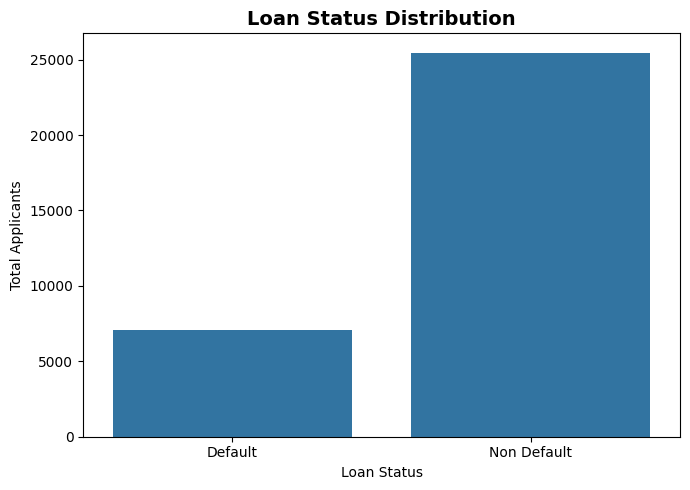

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="loan_status_label"
)

plt.title("Loan Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Total Applicants")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "loan_status_distribution.png", dpi=300)
plt.show()

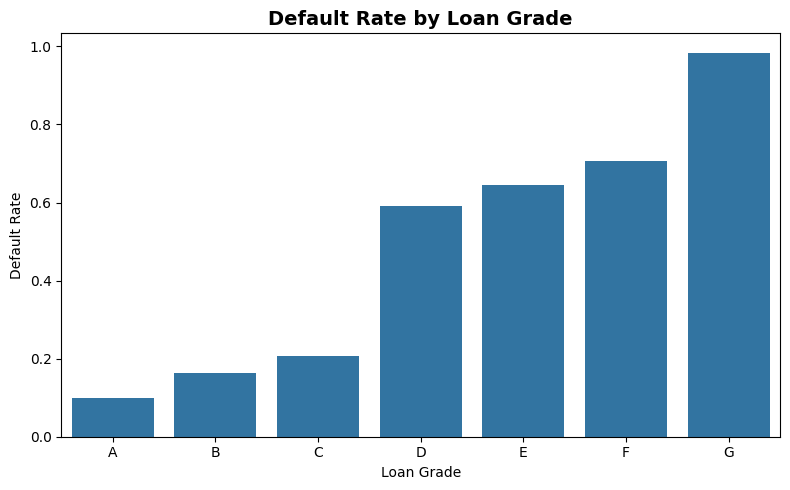

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_by_grade,
    x="loan_grade",
    y="default_rate"
)

plt.title("Default Rate by Loan Grade", fontsize=14, fontweight="bold")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "default_rate_by_loan_grade.png", dpi=300)
plt.show()

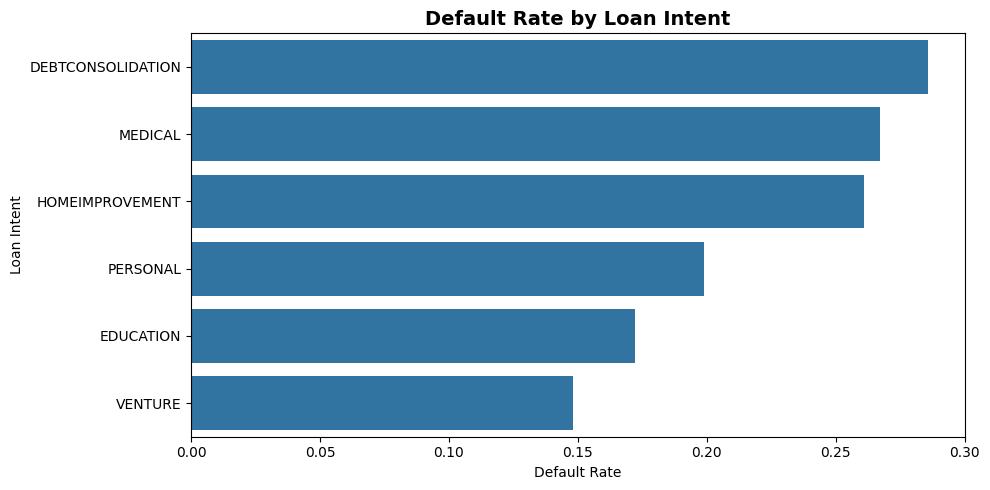

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=default_by_intent,
    x="default_rate",
    y="loan_intent"
)

plt.title("Default Rate by Loan Intent", fontsize=14, fontweight="bold")
plt.xlabel("Default Rate")
plt.ylabel("Loan Intent")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "default_rate_by_loan_intent.png", dpi=300)
plt.show()

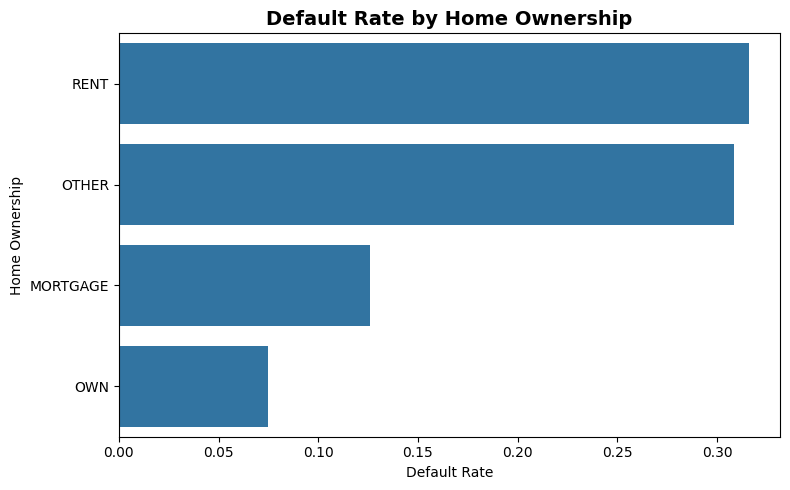

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_by_home,
    x="default_rate",
    y="home_ownership"
)

plt.title("Default Rate by Home Ownership", fontsize=14, fontweight="bold")
plt.xlabel("Default Rate")
plt.ylabel("Home Ownership")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "default_rate_by_home_ownership.png", dpi=300)
plt.show()

In [34]:
# Define target and features
target = "loan_status"

X = df_clean.drop(columns=[
    "loan_status",
    "loan_status_label",
    "risk_level"
])

y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (32581, 11)
y shape: (32581,)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4


In [35]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


C:\Users\rafhi\AppData\Local\Temp\ipykernel_17132\1263164068.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (26064, 11)
X_test: (6517, 11)
y_train distribution:
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64

y_test distribution:
loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


In [37]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [38]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [39]:
model_results = []

trained_models = {}

for model_name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    
    model_results.append(result)
    trained_models[model_name] = clf

model_comparison = pd.DataFrame(model_results).sort_values(
    by="roc_auc",
    ascending=False
)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
2,Gradient Boosting,0.926193,0.945972,0.701828,0.805813,0.926373
1,Random Forest,0.912997,0.837945,0.745429,0.788984,0.925801
0,Logistic Regression,0.813565,0.551467,0.779887,0.646082,0.871179


In [40]:
best_model_name = model_comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Gradient Boosting


In [41]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5095
           1       0.95      0.70      0.81      1422

    accuracy                           0.93      6517
   macro avg       0.93      0.85      0.88      6517
weighted avg       0.93      0.93      0.92      6517



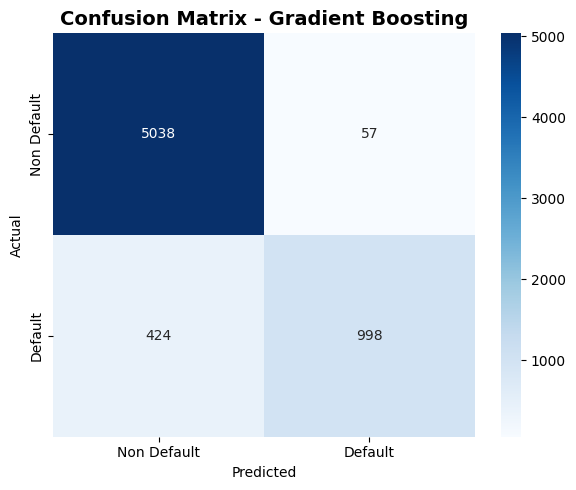

<Figure size 700x500 with 0 Axes>

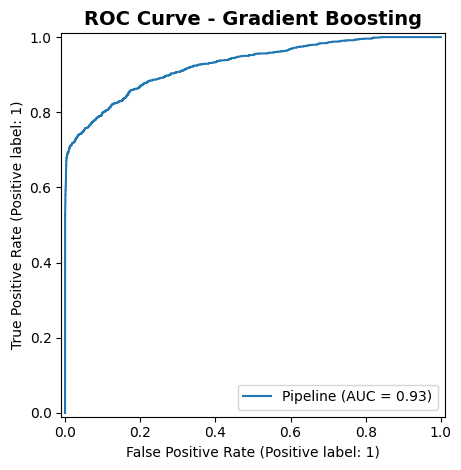

In [43]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non Default", "Default"],
    yticklabels=["Non Default", "Default"]
)

plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "confusion_matrix.png", dpi=300)
plt.show()
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(f"ROC Curve - {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "roc_curve.png", dpi=300)
plt.show()

In [44]:
test_result = X_test.copy()
test_result["actual_loan_status"] = y_test.values
test_result["predicted_loan_status"] = y_pred_best
test_result["default_probability"] = y_proba_best

test_result["credit_risk_segment"] = pd.cut(
    test_result["default_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

test_result[[
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "actual_loan_status",
    "predicted_loan_status",
    "default_probability",
    "credit_risk_segment"
]].head()

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,actual_loan_status,predicted_loan_status,default_probability,credit_risk_segment
6616,22,50000,6000,11.89,0.12,0,0,0.088450,Low Risk
21802,32,52000,7125,7.49,0.14,0,0,0.046839,Low Risk
31886,37,205000,18000,10.39,0.09,0,0,0.037367,Low Risk
17799,26,100000,24000,10.99,0.24,0,0,0.088786,Low Risk
5207,23,44340,3000,12.98,0.07,0,0,0.017799,Low Risk


In [45]:
risk_score_summary = test_result.groupby("credit_risk_segment", as_index=False).agg({
    "actual_loan_status": ["count", "sum"],
    "default_probability": "mean",
    "loan_amnt": "mean",
    "person_income": "mean"
})

risk_score_summary.columns = [
    "credit_risk_segment",
    "total_applicants",
    "total_actual_default",
    "avg_default_probability",
    "avg_loan_amount",
    "avg_income"
]

risk_score_summary["actual_default_rate"] = (
    risk_score_summary["total_actual_default"] /
    risk_score_summary["total_applicants"]
)

risk_score_summary

,credit_risk_segment,total_applicants,total_actual_default,avg_default_probability,avg_loan_amount,avg_income,actual_default_rate
0,Low Risk,5193,352,0.077426,9216.998845,70439.613133,0.067784
1,Medium Risk,358,121,0.429530,10921.717877,64115.787709,0.337989
2,High Risk,966,949,0.890896,11643.944099,44182.750518,0.982402


In [46]:
# Save best model
joblib.dump(best_model, MODEL_PATH + "credit_risk_model.pkl")

# Save processed outputs
df_clean.to_csv(PROCESSED_PATH + "credit_risk_cleaned.csv", index=False)
kpi_summary.to_csv(PROCESSED_PATH + "kpi_summary.csv", index=False)
default_by_home.to_csv(PROCESSED_PATH + "default_by_home_ownership.csv", index=False)
default_by_intent.to_csv(PROCESSED_PATH + "default_by_loan_intent.csv", index=False)
default_by_grade.to_csv(PROCESSED_PATH + "default_by_loan_grade.csv", index=False)
default_by_risk_level.to_csv(PROCESSED_PATH + "default_by_risk_level.csv", index=False)
model_comparison.to_csv(PROCESSED_PATH + "model_comparison.csv", index=False)
test_result.to_csv(PROCESSED_PATH + "credit_risk_scoring_result.csv", index=False)
risk_score_summary.to_csv(PROCESSED_PATH + "risk_score_summary.csv", index=False)

print("All files saved successfully!")
print("Best model:", best_model_name)
print("Model saved to:", MODEL_PATH + "credit_risk_model.pkl")
print("Processed data shape:", df_clean.shape)
print("Scoring result shape:", test_result.shape)

All files saved successfully!
Best model: Gradient Boosting
Model saved to: ../model/credit_risk_model.pkl
Processed data shape: (32581, 14)
Scoring result shape: (6517, 15)
